# From double leaves to circular leaves

A double leaf is a morphism drawn with cuts, bottom to top. A circular leaf is
what is left of it once the rules have run: a `CircularDecorated` diagram that
no rule in the registry touches any more. The map between the two is
`cl_reduce`, and collected over the whole basis it is the decomposition matrix
`circular_dl_matrix`:

$$\mathrm{circular}(DL_k) \;=\; \sum_l M_{kl}\cdot CL_l .$$

The point of this notebook is that `M` is **not** the identity. On small words
it looks like it is, which is misleading, so every example below is one where
something actually happens: a double leaf that becomes a sum of several circular
leaves, coefficients in `R = ℚ[α₁,α₂,α₃]` rather than in ℚ, and a pair of words
where `M` is not even square.

In [1]:
using DiagrammaticHecke
debug_circular(true)
dl_warnings!(false)      # the findings below are the subject, not a surprise


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


true

## 1. One double leaf, reduced

`cl_reduce(m)` takes any morphism and returns the sum of circular leaves it
reduces to. Start with a double leaf of `121 → 121` in degree 2.

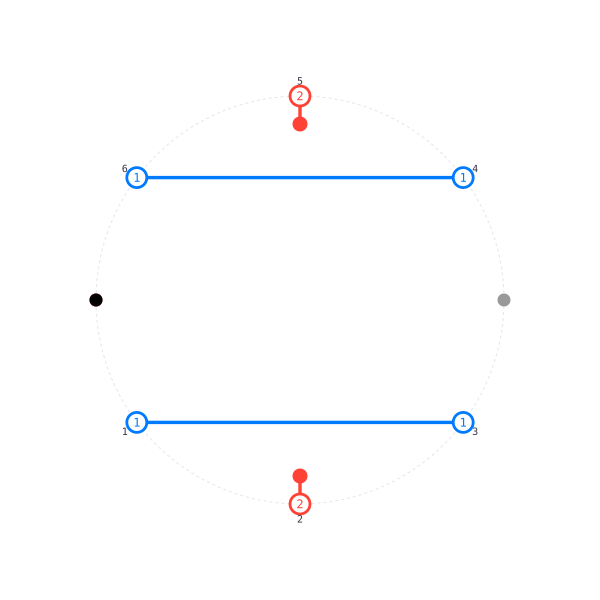

DL of degree 2:  e = [1, 0, 1]  f = [1, 0, 1]  z = Int64[]


In [2]:
x = [1, 2, 1]
t = dl(x, x)
en = t[2][1]
println("DL of degree 2:  e = ", en.e, "  f = ", en.f, "  z = ", en.z)
display(en.morphism)

1 circular leaf/leaves
Coefficient 1   degree 2
   Labels: —   outer: 1   nodes: [(:mono, [2]), (:mono, [2])]


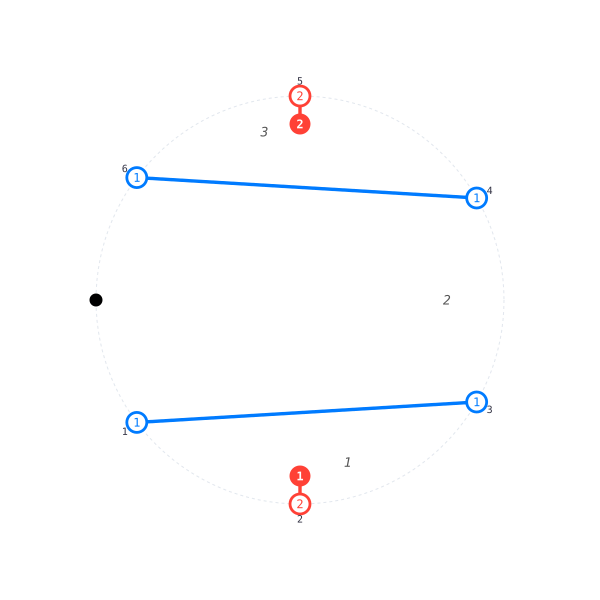

In [3]:
c = cl_reduce(en.morphism)
println(length(pairs_of(c)), " circular leaf/leaves")
show_combo(c)

## 2. The decomposition matrix of `121`

Doing that for every double leaf gives the matrix. For `121` it comes out
square, unitriangular and, in fact, a permutation: every double leaf is one
circular leaf. This is the case that makes the map look trivial.

In [4]:
dec = circular_dl_matrix(x, x)
println("M is ", size(dec.M, 1), " x ", size(dec.M, 2))
circular_dl_triangular(dec)

M is 12 x 12


(square = true, triangular = true, block_diagonal = true, unitriangular = true, partner = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], perm = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], excess_by_degree = Pair{Int64, Int64}[])

In [5]:
# how many circular leaves each row uses
using Printf
for (k, en) in enumerate(dec.rows)
    nz = count(l -> !iszero(dec.M[k, l]), 1:size(dec.M, 2))
    @printf("row %2d  degree %2d   %d leaf/leaves\n", k, en.degree, nz)
end

row  1  degree  0   1 leaf/leaves
row  2  degree  0   1 leaf/leaves
row  3  degree  2   1 leaf/leaves
row  4  degree  2   1 leaf/leaves
row  5  degree  2   1 leaf/leaves
row  6  degree  2   1 leaf/leaves
row  7  degree  2   1 leaf/leaves
row  8  degree  4   1 leaf/leaves
row  9  degree  4   1 leaf/leaves
row 10  degree  4   1 leaf/leaves
row 11  degree  4   1 leaf/leaves
row 12  degree  6   1 leaf/leaves


## 3. The first nontrivial row: `1212`

`1212` is the smallest pair in the package where a double leaf does **not**
reduce to a single circular leaf. Row 17 of its 44×44 matrix is a sum of two,
both with coefficient 1.

The reduction is worth watching rather than just reading off, so the row is
recomputed here from the double leaf itself.

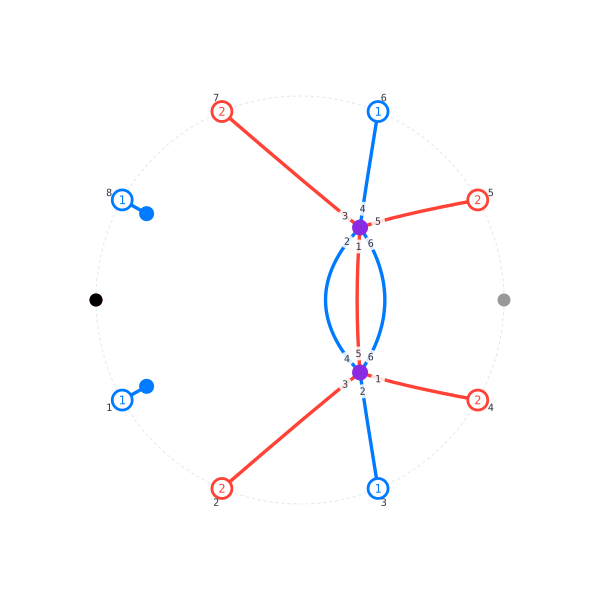

row 17:  degree 2  e = [0, 1, 1, 1]  f = [0, 1, 1, 1]  z = [1, 2, 1]


In [6]:
y = [1, 2, 1, 2]
ty = dl(y, y)
ey = dl_entries(ty)[17]
println("row 17:  degree ", ey.degree, "  e = ", ey.e, "  f = ", ey.f, "  z = ", ey.z)
display(ey.morphism)

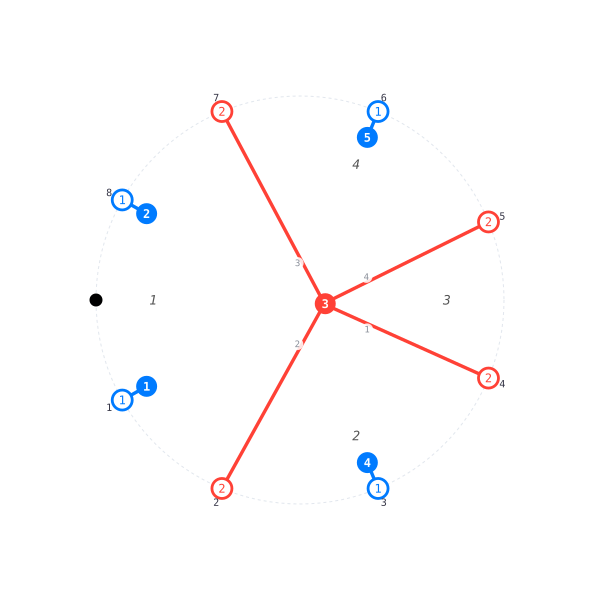

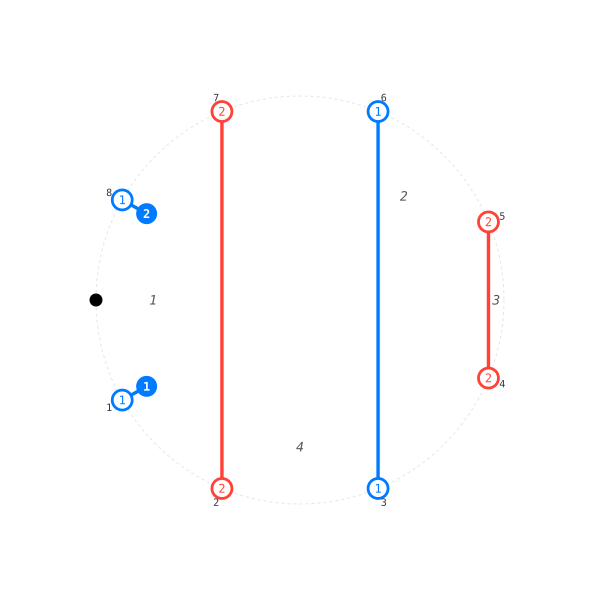

2 circular leaves — the row is not a single leaf
Coefficient 1   degree 2
   Labels: —   outer: 1   nodes: [(:mixed, [1]), (:mixed, [1]), (:mono, [2, 2, 2, 2]), (:mixed, [1]), (:mixed, [1])]
Coefficient 1   degree 2
   Labels: —   outer: 1   nodes: [(:mixed, [1]), (:mixed, [1])]


In [7]:
cy = cl_reduce(ey.morphism)
println(length(pairs_of(cy)), " circular leaves — the row is not a single leaf")
show_combo(cy)

The two leaves are genuinely different diagrams, not two drawings of one: their
canonical keys differ, which is exactly the equality `CircularCombo` uses to
decide whether two terms collapse.

In [8]:
keys17 = [circular_canonical_key(d) for (d, _) in pairs_of(cy)]
println("two distinct keys: ", length(unique(keys17)) == 2)
println("degrees of the leaves: ", [circular_degree(d) for (d, _) in pairs_of(cy)])
println("degree of the double leaf: ", ey.degree)

two distinct keys: true
degrees of the leaves: [2, 2]
degree of the double leaf: 2


## 4. Polynomial coefficients: `21232`

Everything so far had coefficients 1. That is an artefact of the small words.
On `21232 → 21232` the coefficients live in `R`: `−α₂²`, `α₁ − α₂`, `α₂⁴`.

This cell takes about a minute — it reduces all 72 double leaves.

In [9]:
z = [2, 1, 2, 3, 2]
@time decz = circular_dl_matrix(z, z)
println("M is ", size(decz.M, 1), " x ", size(decz.M, 2))

 39.138595 seconds (28.88 M allocations: 1.479 GiB, 1.91% gc time, 97.89% compilation time)
M is 72 x 72


In [10]:
n, m = size(decz.M)
for k in 1:n
    nz = [(l, decz.M[k, l]) for l in 1:m if !iszero(decz.M[k, l])]
    poly = any(!iszero(degree(c)) for (_, c) in nz)
    (length(nz) > 1 || poly) || continue
    println("row ", k, "  degree ", decz.rows[k].degree, "  e = ", decz.rows[k].e,
            "  f = ", decz.rows[k].f)
    for (l, c) in nz
        println("      CL", l, "  ·  ", c)
    end
end

row 1  degree 0  e = [1, 1, 1, 0, 0]  f = [1, 1, 1, 0, 0]
      CL1  ·  1
      CL2  ·  1
row 2  degree 0  e = [1, 1, 1, 1, 1]  f = [1, 1, 1, 1, 1]
      CL3  ·  1
      CL4  ·  1
row 7  degree 2  e = [1, 1, 0, 0, 1]  f = [1, 1, 1, 0, 0]
      CL2  ·  -α₂
      CL7  ·  1
      CL8  ·  1
      CL9  ·  1
row 8  degree 2  e = [1, 1, 1, 0, 0]  f = [1, 1, 0, 0, 1]
      CL2  ·  -α₂
      CL10  ·  1
      CL11  ·  1
      CL12  ·  1
row 9  degree 2  e = [1, 1, 1, 1, 0]  f = [1, 1, 1, 1, 0]
      CL13  ·  1
      CL14  ·  1
row 15  degree 2  e = [1, 1, 1, 0, 1]  f = [1, 1, 1, 0, 1]
      CL2  ·  α₁ - 2*α₂
      CL5  ·  1
      CL7  ·  1
      CL11  ·  1
      CL12  ·  1
      CL16  ·  1
row 28  degree 4  e = [1, 1, 0, 0, 1]  f = [1, 1, 0, 0, 1]
      CL2  ·  α₂^2
      CL7  ·  -α₂
      CL8  ·  -α₂
      CL11  ·  -α₂
      CL12  ·  -α₂
      CL28  ·  1
      CL29  ·  1
      CL30  ·  1
      CL31  ·  1
      CL32  ·  1
row 37  degree 4  e = [1, 1, 0, 0, 0]  f = [1, 1, 1, 0, 1]
      CL2  ·  α

Row 15 is the shortest one with a coefficient that is neither a constant nor a
monomial: `α₁ − α₂` on the second circular leaf. Row 28 shows how far this can
go — ten leaves, with `α₂⁴` and four times `−α₂²`.

Drawing row 15 term by term: the double leaf, then its circular leaves with
their coefficients.

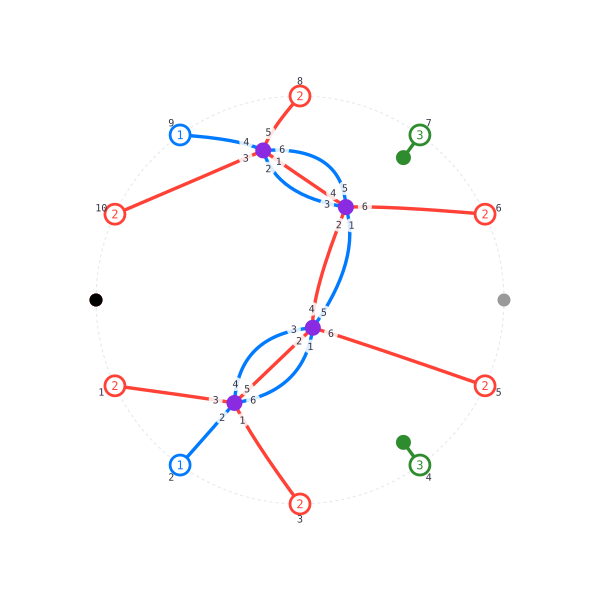

degree 2  e = [1, 1, 1, 0, 1]  f = [1, 1, 1, 0, 1]  z = [2, 1]


In [11]:
e15 = decz.rows[15]
println("degree ", e15.degree, "  e = ", e15.e, "  f = ", e15.f, "  z = ", e15.z)
display(e15.morphism)

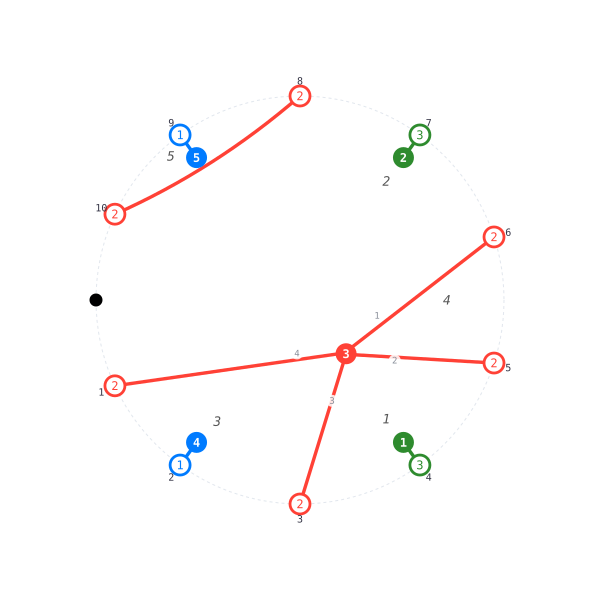

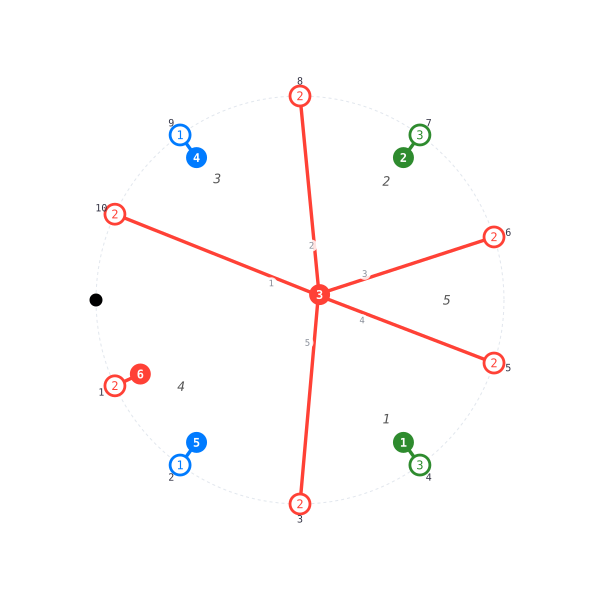

Coefficient 1   degree 2
   Labels: —   outer: 1   nodes: [(:mixed, [3]), (:mixed, [3]), (:mono, [2, 2, 2, 2]), (:mixed, [1]), (:mixed, [1])]
Coefficient 1   degree 2
   Labels: —   outer: 1   nodes: [(:mixed, [3]), (:mixed, [3]), (:mono, [2, 2, 2, 2, 2]), (:mixed, [1]), (:mixed, [1]), (:mono, [2])]
Coefficient α₁ - 2*α₂   degree 2
   Labels: —   outer: 1   nodes: [(:mixed, [3]), (:mixed, [3]), (:mono, [2, 2, 2, 2, 2, 2]), (:mixed, [1]), (:mixed, [1])]
Coefficient 1   degree 2
   Labels: —   outer: 1   nodes: [(:mixed, [3]), (:mixed, [3]), (:mono, [2, 2, 2, 2, 2]), (:mixed, [1]), (:mixed, [1]), (:mono, [2])]
Coefficient 1   degree 2
   Labels: —   outer: 1   nodes: [(:mixed, [3]), (:mixed, [3])]
Coefficient 1   degree 2
   Labels: —   outer: 1   nodes: [(:mixed, [3]), (:mixed, [3]), (:mono, [2, 2, 2]), (:mixed, [1]), (:mixed, [1]), (:mono, [2, 2, 2])]


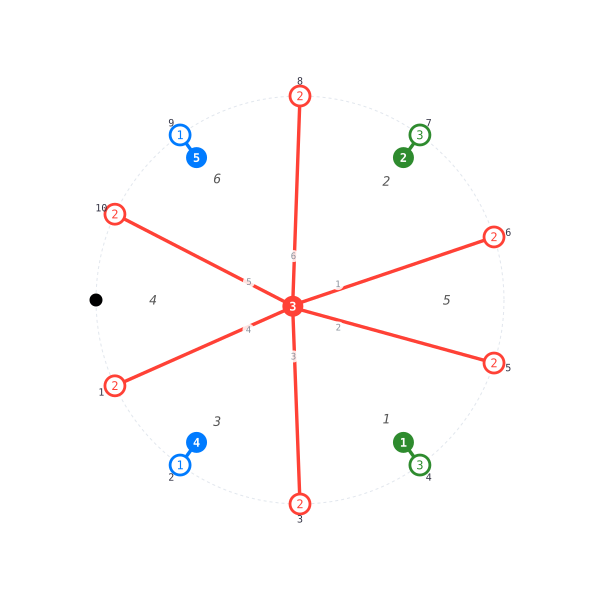

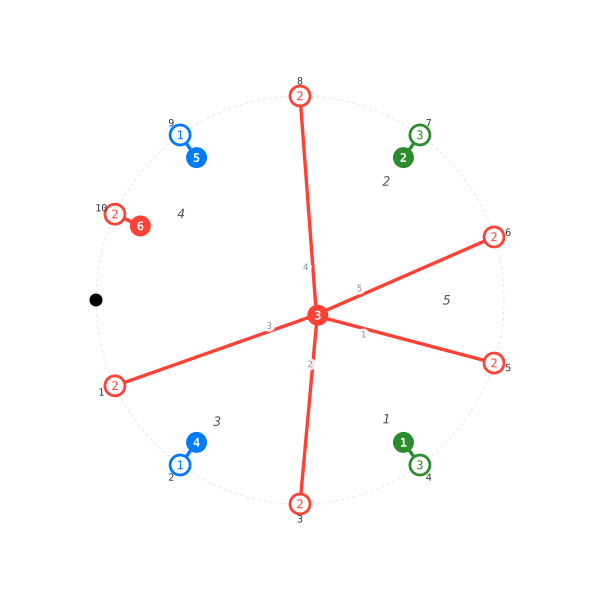

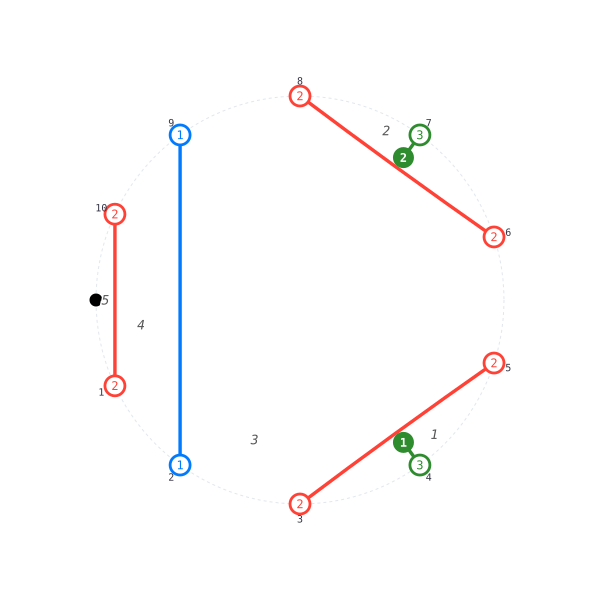

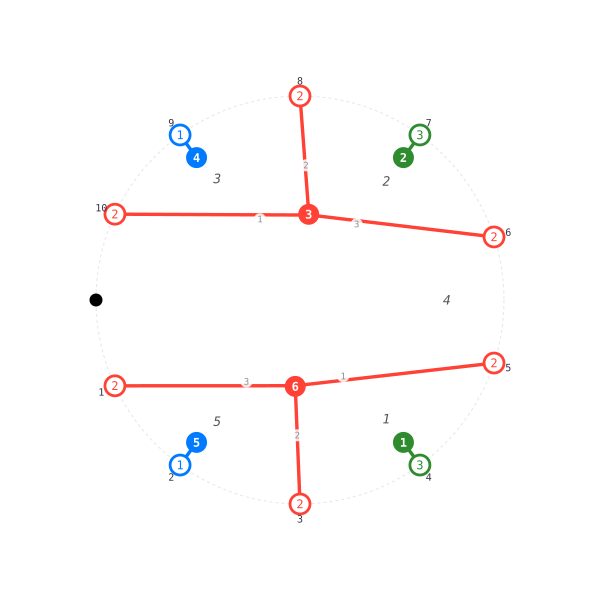

In [12]:
show_combo(cl_reduce(e15.morphism))

## 5. Which leaves count as basis elements

`cl_basis(x, y)` keeps the circular leaves that occur at least once with a
**scalar** coefficient — a leaf that only ever appears multiplied by a genuine
polynomial is not a basis element, it is a higher-degree correction. That
filter is why `cl_basis` can be shorter than the column count of `M`.

In [13]:
b = cl_basis(x, x)
println("121: ", length(b.leaves), " leaves, degrees ", b.degrees,
        " (columns of M: ", size(dec.M, 2), ")")
by = cl_basis(y, y)
println("1212: ", length(by.leaves), " leaves out of ", length(dl_entries(ty)), " double leaves")

121: 12 leaves, degrees [2, 6, 4, 4, 2, 0, 2, 2, 4, 0, 4, 2] (columns of M: 12)
1212: 44 leaves out of 44 double leaves


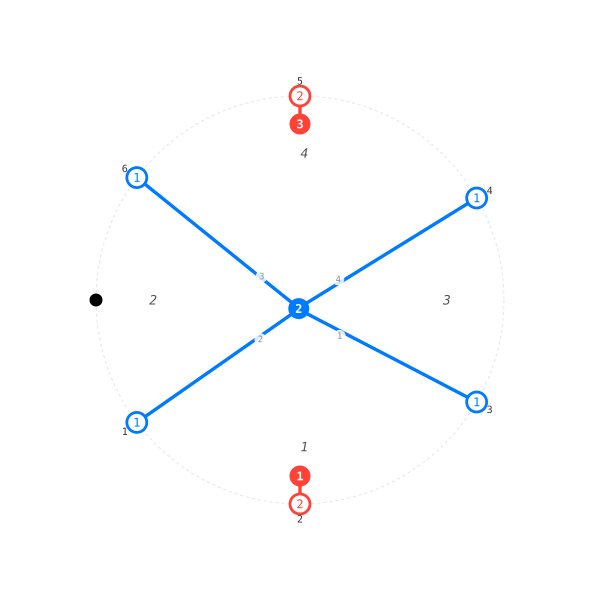

leaf 6, degree 0
leaf 10, degree 0


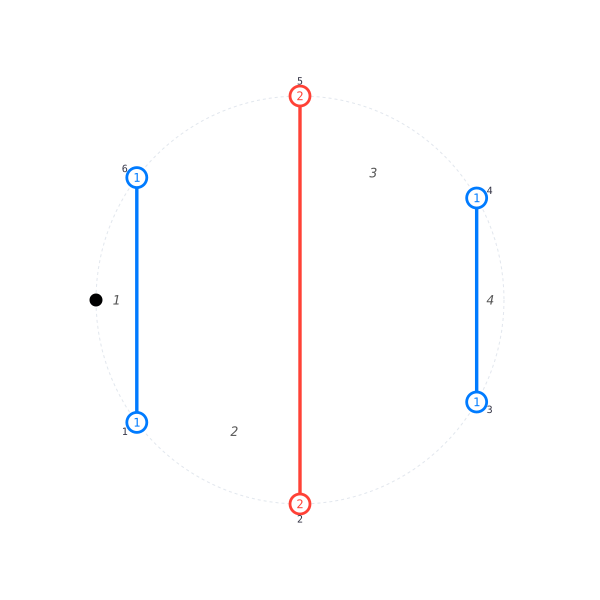

In [14]:
# the degree-0 leaves of 121, drawn
for (i, d) in enumerate(b.leaves)
    b.degrees[i] == 0 || continue
    println("leaf ", i, ", degree 0")
    display(d)
end

## 6. Reading a sum in those coordinates

`cl_coordinates` writes a reduced sum in the coordinates of a `CLBasis`. What it
cannot place goes into `rest` — a finding about the basis, not an error.

In [15]:
coords = cl_coordinates(cl_reduce(en.morphism), b)
println("coefficients: ", coords.coeffs)
println("rest is empty: ", isempty(pairs_of(coords.rest)))

coefficients: AbstractAlgebra.Generic.MPoly{Rational{BigInt}}[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
rest is empty: true


Notebook 08 picks this up from the other side: writing an **arbitrary**
morphism — not just a basis element — in the DL basis, moving between the two
bases, and expressing a composite again.